# Customer Churn — EDA & Model Training

IBM Telco customer churn dataset. This notebook does EDA (distributions, cardinality, churn rate by segment) and model training/evaluation. Cleaning lives in `data.py`; the model in `model.py`.

## 1. Setup and load

In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# make repo root importable + set data path (works from notebooks/ or root)
if os.path.isdir("../data"):
    os.chdir("..")
sys.path.insert(0, ".")

from data import load_data, audit_data, churn_rate_by, corr_with_churn

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4)

df = load_data()
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Audit summary (structural checks)

In [2]:
rep = audit_data(df)
print("class balance:", rep["class_balance"])
print("near-duplicate rows:", rep["near_duplicate_rows"])
print("total charges blank count:", rep["totalcharges_blank_count"])
print("blank tenure values:", rep["totalcharges_blank_tenure"])
print("leakage candidates:", rep["leakage_candidates"])

class balance: {'No': 0.7346, 'Yes': 0.2654}
near-duplicate rows: 22
total charges blank count: 11
blank tenure values: [0]
leakage candidates: []


## 3. Numeric distributions

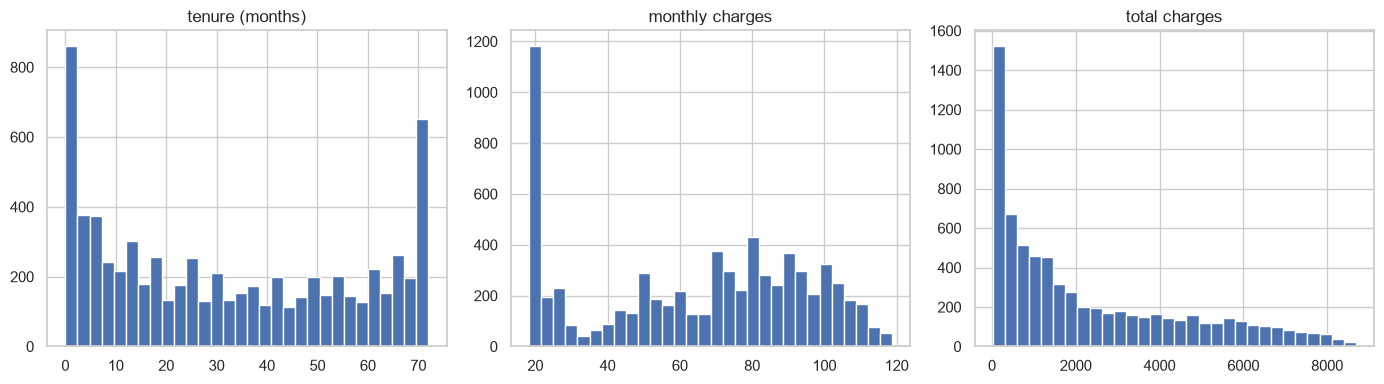

        tenure  MonthlyCharges
count  7043.00         7043.00
mean     32.37           64.76
std      24.56           30.09
min       0.00           18.25
25%       9.00           35.50
50%      29.00           70.35
75%      55.00           89.85
max      72.00          118.75
count    7032.00
mean     2283.30
std      2266.77
min        18.80
25%       401.45
50%      1397.48
75%      3794.74
max      8684.80


In [3]:
# TotalCharges is text in the raw file, coerce to numeric for these plots
tc = pd.to_numeric(df["TotalCharges"], errors="coerce")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(df["tenure"], bins=30)
axes[0].set_title("tenure (months)")
axes[1].hist(df["MonthlyCharges"], bins=30)
axes[1].set_title("monthly charges")
axes[2].hist(tc.dropna(), bins=30)
axes[2].set_title("total charges")
plt.tight_layout()
plt.show()

print(df[["tenure", "MonthlyCharges"]].describe().round(2).to_string())
print(tc.describe().round(2).to_string())

## 4. Categorical cardinality and value counts

In [4]:
cat_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
cat_cols = [c for c in cat_cols if c not in ("customerID", "Churn")]
for c in cat_cols:
    print(f"--- {c} ({df[c].nunique()} unique) ---")
    print(df[c].value_counts(dropna=False).to_string())
    print()

--- gender (2 unique) ---
gender
Male      3555
Female    3488

--- Partner (2 unique) ---
Partner
No     3641
Yes    3402

--- Dependents (2 unique) ---
Dependents
No     4933
Yes    2110

--- PhoneService (2 unique) ---
PhoneService
Yes    6361
No      682

--- MultipleLines (3 unique) ---
MultipleLines
No                  3390
Yes                 2971
No phone service     682

--- InternetService (3 unique) ---
InternetService
Fiber optic    3096
DSL            2421
No             1526

--- OnlineSecurity (3 unique) ---
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526

--- OnlineBackup (3 unique) ---
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526

--- DeviceProtection (3 unique) ---
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526

--- TechSupport (3 unique) ---
TechSupport
No                     3473
Yes                    2044
No i

## 5. Churn rate by segment (bivariate)

In [5]:
for c in ["Contract", "InternetService", "PaymentMethod", "gender", "SeniorCitizen"]:
    t = churn_rate_by(df, c)
    print(f"--- {c} ---")
    print(t.round(3).to_string())
    print()

--- Contract ---
                total  churned  churn_rate
Contract                                  
Month-to-month   3875     1655       0.427
One year         1473      166       0.113
Two year         1695       48       0.028

--- InternetService ---
                 total  churned  churn_rate
InternetService                            
Fiber optic       3096     1297       0.419
DSL               2421      459       0.190
No                1526      113       0.074

--- PaymentMethod ---
                           total  churned  churn_rate
PaymentMethod                                        
Electronic check            2365     1071       0.453
Mailed check                1612      308       0.191
Bank transfer (automatic)   1544      258       0.167
Credit card (automatic)     1522      232       0.152

--- gender ---
        total  churned  churn_rate
gender                            
Female   3488      939       0.269
Male     3555      930       0.262

--- SeniorCitizen -

## 6. Correlation with churn

numeric corr with churn (abs sorted):
tenure            0.352
MonthlyCharges    0.193
SeniorCitizen     0.151


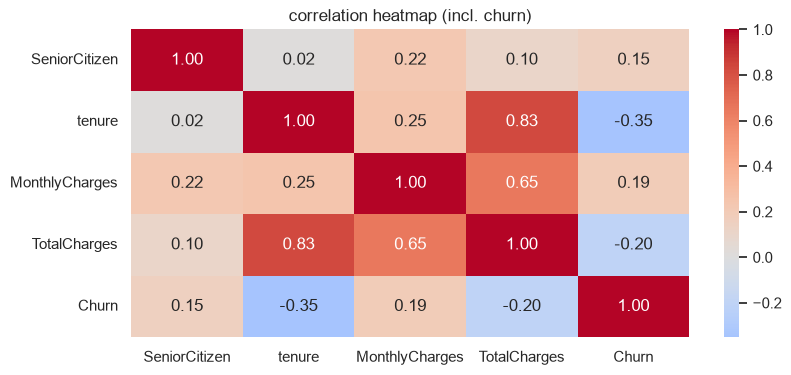

In [6]:
print("numeric corr with churn (abs sorted):")
print(corr_with_churn(df).round(3).to_string())

num = df.select_dtypes(include="number").copy()
num["TotalCharges"] = tc
num["Churn"] = (df["Churn"] == "Yes").astype(int)
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("correlation heatmap (incl. churn)")
plt.show()

## 7. Missingness and leakage (deep dive)

Formal look at the 11 blank `TotalCharges` cells and why nothing here is label leakage.

In [7]:
# the 11 blank TotalCharges rows: are they random, or structurally determined?
tc = pd.to_numeric(df["TotalCharges"], errors="coerce")
blank = tc.isna()

print("blank TotalCharges rows:", blank.sum())
print("tenure == 0 rows:", (df.tenure == 0).sum())
print("one-to-one (tenure==0 <-> blank):", (df.tenure == 0).sum() == blank.sum())
print("churn rate, blank rows:", round((df.loc[blank, "Churn"] == "Yes").mean(), 3))
print("churn rate, overall:", round((df.Churn == "Yes").mean(), 3))
print("contracts among blank rows:", df.loc[blank, "Contract"].value_counts().to_dict())

blank TotalCharges rows: 11
tenure == 0 rows: 11
one-to-one (tenure==0 <-> blank): True
churn rate, blank rows: 0.0
churn rate, overall: 0.265
contracts among blank rows: {'Two year': 10, 'One year': 1}


In [8]:
# leakage reasoning: identifier + redundancy, nothing post-outcome
print("unique customerIDs:", df.customerID.nunique(), "== nrows:", df.customerID.nunique() == len(df))
print("corr(TotalCharges, tenure):", round(tc.corr(df.tenure), 3))
print("corr(TotalCharges, MonthlyCharges):", round(tc.corr(df.MonthlyCharges), 3))
print("leakage-name search:", audit_data(df)["leakage_candidates"])

unique customerIDs: 7043 == nrows: True
corr(TotalCharges, tenure): 0.826
corr(TotalCharges, MonthlyCharges): 0.651


leakage-name search: []
